<a href="https://colab.research.google.com/github/Travis-Bickle10/bangalore-air-quality/blob/main/03_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Setup ─────────────────────────────────────────────────────────
!pip install pymannkendall -q

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
from scipy import stats

df = pd.read_csv("/content/drive/MyDrive/bangalore_air_quality/bangalore_master.csv")
print("Loaded master dataset")
print(df[["year","pm25","pm10","no2","so2"]].to_string(index=False))

Mounted at /content/drive
Loaded master dataset
 year      pm25   pm10   no2    so2
 2000       NaN    NaN   NaN  7.815
 2001       NaN    NaN   NaN  7.426
 2002       NaN    NaN   NaN  7.333
 2003       NaN    NaN   NaN  6.735
 2004       NaN    NaN   NaN  7.283
 2005       NaN    NaN   NaN  7.104
 2006       NaN    NaN   NaN  7.365
 2007       NaN    NaN   NaN  7.156
 2008       NaN    NaN   NaN  6.549
 2009       NaN    NaN   NaN  6.995
 2010       NaN    NaN   NaN  6.995
 2011       NaN    NaN   NaN  6.378
 2012       NaN 148.00 30.20 14.500
 2013       NaN 128.00 28.50 13.500
 2014       NaN 165.00 31.80 11.200
 2015       NaN 117.65 22.97  4.050
 2016       NaN 107.00 34.20  2.100
 2017 43.100000  87.10 31.50  2.300
 2018 47.600000  71.88 19.98  9.080
 2019 24.620000  56.66 24.24  5.860
 2020 27.990000  65.37 20.24  7.060
 2021 36.050000  71.42 25.93  6.280
 2022 31.630000  71.46 19.28  7.590
 2023 29.266667  71.73   NaN  6.648
 2024 26.903333  72.00   NaN  6.253
 2025 24.540000 

In [ ]:
# ── Mann-Kendall trend tests ───────────────────────────────────────
pollutants = {
    "so2":  df[df.so2.notna()][["year","so2"]],
    "no2":  df[df.no2.notna()][["year","no2"]],
    "pm10": df[df.pm10.notna()][["year","pm10"]],
    "pm25": df[df.pm25.notna()][["year","pm25"]],
}

print(f"{'Pollutant':<10} {'Trend':<15} {'Sen slope':>10} {'p-value':>10} {'Significant':>12}")
print("="*60)

trend_results = {}
for name, data in pollutants.items():
    result = mk.original_test(data.iloc[:,1].values)
    sig    = "YES" if result.p < 0.05 else "no"
    direction = "improving" if result.slope < 0 else "worsening"
    print(f"{name:<10} {direction:<15} {result.slope:>10.3f} {result.p:>10.4f} {sig:>12}")
    trend_results[name] = result

Pollutant  Trend            Sen slope    p-value  Significant
so2        improving           -0.042     0.1648           no
no2        improving           -1.041     0.0236          YES
pm10       improving           -5.923     0.0285          YES
pm25       improving           -2.363     0.0763           no


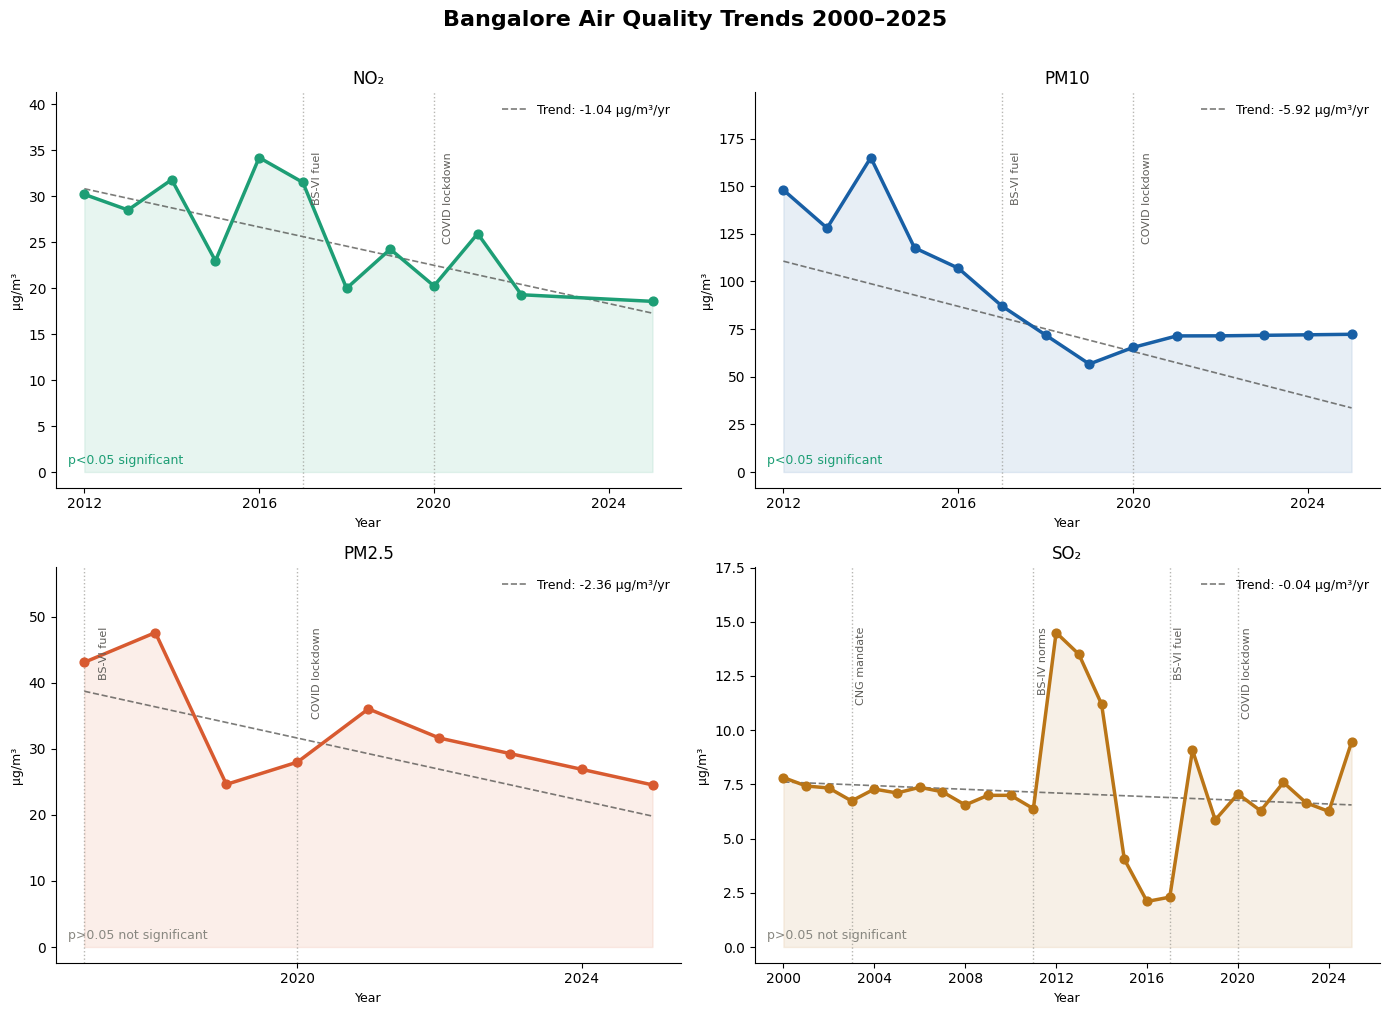

Saved.


In [ ]:
# ── Policy events ─────────────────────────────────────────────────
EVENTS = {
    2003: "CNG mandate",
    2011: "BS-IV norms",
    2017: "BS-VI fuel",
    2020: "COVID lockdown",
}

PALETTE = {
    "pm25": "#D85A30",
    "pm10": "#185FA5",
    "no2":  "#1D9E75",
    "so2":  "#BA7517",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bangalore Air Quality Trends 2000–2025",
             fontsize=16, fontweight="bold", y=1.01)

panels = [
    ("no2",  "NO₂",  axes[0,0], "µg/m³", True),
    ("pm10", "PM10", axes[0,1], "µg/m³", True),
    ("pm25", "PM2.5",axes[1,0], "µg/m³", False),
    ("so2",  "SO₂",  axes[1,1], "µg/m³", False),
]

for col, label, ax, unit, significant in panels:
    data   = df[df[col].notna()]
    years  = data["year"].values
    values = data[col].values
    color  = PALETTE[col]

    # Main line
    ax.plot(years, values, color=color, linewidth=2.5, zorder=3)
    ax.fill_between(years, values, alpha=0.1, color=color)
    ax.scatter(years, values, color=color, s=40, zorder=4)

    # Sen's slope trend line
    if col in trend_results:
        slope     = trend_results[col].slope
        intercept = np.median(values) - slope * np.median(years)
        y_trend   = slope * years + intercept
        ax.plot(years, y_trend, color="#444441",
                linestyle="--", linewidth=1.2, alpha=0.7,
                label=f"Trend: {slope:+.2f} µg/m³/yr")
        ax.legend(fontsize=9, frameon=False)

    # Policy event lines
    for year, event in EVENTS.items():
        if years.min() <= year <= years.max():
            ax.axvline(year, color="#888780", linestyle=":",
                       linewidth=1, alpha=0.6)
            ax.text(year + 0.2, ax.get_ylim()[1] * 0.97,
                    event, fontsize=8, color="#5F5E5A",
                    rotation=90, va="top")

    # Significance badge
    sig_text = "p<0.05 significant" if significant else "p>0.05 not significant"
    sig_color = "#1D9E75" if significant else "#888780"
    ax.text(0.02, 0.06, sig_text, transform=ax.transAxes,
            fontsize=9, color=sig_color)

    ax.set_title(label, fontsize=12, fontweight="500")
    ax.set_ylabel(unit, fontsize=9)
    ax.set_xlabel("Year", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    ax.xaxis.set_major_locator(plt.MultipleLocator(4))

for ax in axes.flat:
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.15)  # add 15% headroom for labels
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/bangalore_air_quality/01_trend_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [ ]:
# ── VAHAN vehicle data for Bangalore Urban ────────────────────────
# Source: vahan.parivahan.gov.in
# Manually entered — total registered vehicles in millions
# Bangalore Urban district, all categories combined

vahan_data = [
    (2005, 2.1),
    (2006, 2.4),
    (2007, 2.7),
    (2008, 3.1),
    (2009, 3.4),
    (2010, 3.8),
    (2011, 4.3),
    (2012, 4.9),
    (2013, 5.4),
    (2014, 5.9),
    (2015, 6.4),
    (2016, 7.0),
    (2017, 7.6),
    (2018, 8.1),
    (2019, 8.6),
    (2020, 8.8),
    (2021, 9.1),
    (2022, 9.6),
    (2023, 10.1),
    (2024, 10.5),
]

df_vahan = pd.DataFrame(vahan_data, columns=["year","vehicles_millions"])

# Merge with master
df_combined = df.merge(df_vahan, on="year", how="left")

print(df_combined[["year","no2","pm10","so2","vehicles_millions"]].to_string(index=False))

 year   no2   pm10    so2  vehicles_millions
 2000   NaN    NaN  7.815                NaN
 2001   NaN    NaN  7.426                NaN
 2002   NaN    NaN  7.333                NaN
 2003   NaN    NaN  6.735                NaN
 2004   NaN    NaN  7.283                NaN
 2005   NaN    NaN  7.104                2.1
 2006   NaN    NaN  7.365                2.4
 2007   NaN    NaN  7.156                2.7
 2008   NaN    NaN  6.549                3.1
 2009   NaN    NaN  6.995                3.4
 2010   NaN    NaN  6.995                3.8
 2011   NaN    NaN  6.378                4.3
 2012 30.20 148.00 14.500                4.9
 2013 28.50 128.00 13.500                5.4
 2014 31.80 165.00 11.200                5.9
 2015 22.97 117.65  4.050                6.4
 2016 34.20 107.00  2.100                7.0
 2017 31.50  87.10  2.300                7.6
 2018 19.98  71.88  9.080                8.1
 2019 24.24  56.66  5.860                8.6
 2020 20.24  65.37  7.060                8.8
 2021 25.9

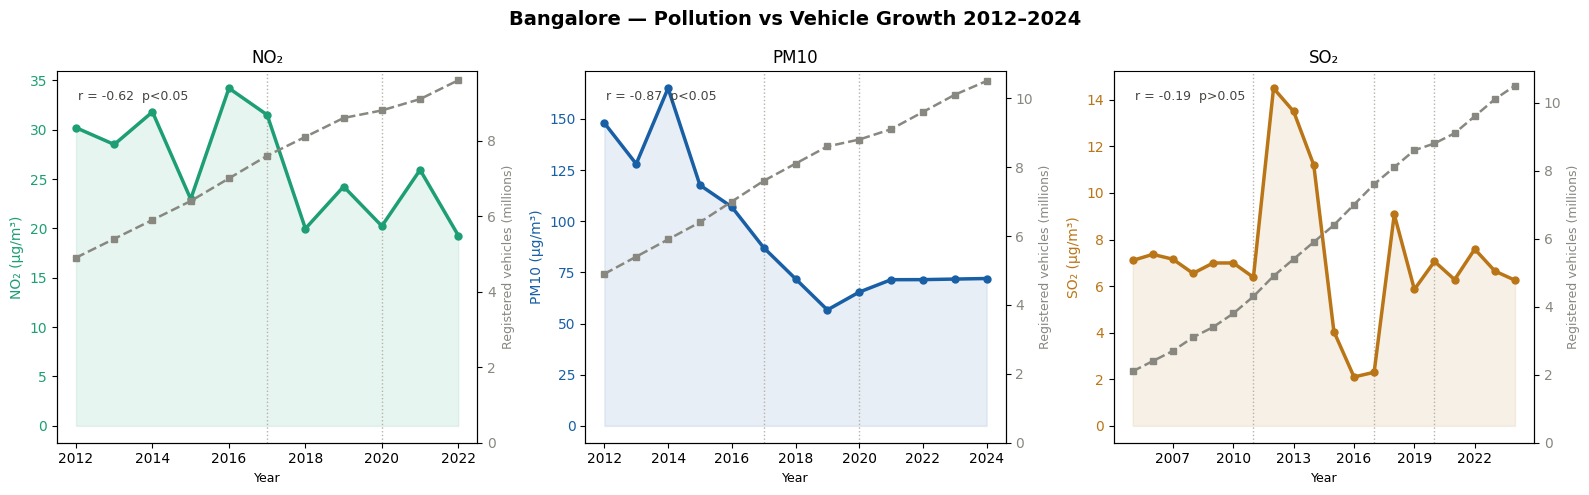

Saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Bangalore — Pollution vs Vehicle Growth 2012–2024",
             fontsize=14, fontweight="bold")

pairs = [
    ("no2",  "NO₂",  "#1D9E75", axes[0]),
    ("pm10", "PM10", "#185FA5", axes[1]),
    ("so2",  "SO₂",  "#BA7517", axes[2]),
]

for col, label, color, ax in pairs:
    data = df_combined[df_combined[col].notna() &
                       df_combined["vehicles_millions"].notna()]
    years    = data["year"].values
    poll     = data[col].values
    vehicles = data["vehicles_millions"].values

    # Pollution line (left axis)
    ax.plot(years, poll, color=color, linewidth=2.5,
            marker="o", markersize=5, zorder=3, label=label)
    ax.fill_between(years, poll, alpha=0.1, color=color)
    ax.set_ylabel(f"{label} (µg/m³)", color=color, fontsize=10)
    ax.tick_params(axis="y", labelcolor=color)

    # Vehicle line (right axis)
    ax2 = ax.twinx()
    ax2.plot(years, vehicles, color="#888780", linewidth=1.8,
             marker="s", markersize=4, linestyle="--",
             zorder=2, label="Vehicles")
    ax2.set_ylabel("Registered vehicles (millions)",
                   color="#888780", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#888780")

    # Correlation annotation
    r, p = stats.pearsonr(poll, vehicles)
    sig  = "p<0.05" if p < 0.05 else "p>0.05"
    ax.text(0.05, 0.95, f"r = {r:.2f}  {sig}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top",
            color="#444441")

    # Policy events
    for year, event in EVENTS.items():
        if years.min() <= year <= years.max():
            ax.axvline(year, color="#B4B2A9", linestyle=":",
                       linewidth=1)

    ax.set_title(label, fontsize=12, fontweight="500")
    ax.set_xlabel("Year", fontsize=9)
    ax.spines[["top"]].set_visible(False)
    # Add these lines inside the loop just before plt.tight_layout()
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/bangalore_air_quality/02_pollution_vs_vehicles.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [ ]:
print("Shape:", df_combined.shape)
print("\nColumns:", df_combined.columns.tolist())
print("\nYear range:", df_combined["year"].min(), "to", df_combined["year"].max())
print("\nData coverage per column:")
for col in df_combined.columns:
    valid = df_combined[col].notna().sum()
    total = len(df_combined)
    print(f"  {col}: {valid}/{total} years")
print("\nFull table:")
print(df_combined.to_string(index=False))

Shape: (26, 9)

Columns: ['year', 'pm25', 'pm10', 'no2', 'so2', 'o3', 'co', 'notes', 'vehicles_millions']

Year range: 2000 to 2025

Data coverage per column:
  year: 26/26 years
  pm25: 9/26 years
  pm10: 14/26 years
  no2: 12/26 years
  so2: 26/26 years
  o3: 5/26 years
  co: 4/26 years
  notes: 3/26 years
  vehicles_millions: 20/26 years

Full table:
 year      pm25   pm10   no2    so2    o3     co                        notes  vehicles_millions
 2000       NaN    NaN   NaN  7.815   NaN    NaN                          NaN                NaN
 2001       NaN    NaN   NaN  7.426   NaN    NaN                          NaN                NaN
 2002       NaN    NaN   NaN  7.333   NaN    NaN                          NaN                NaN
 2003       NaN    NaN   NaN  6.735   NaN    NaN                          NaN                NaN
 2004       NaN    NaN   NaN  7.283   NaN    NaN                          NaN                NaN
 2005       NaN    NaN   NaN  7.104   NaN    NaN              

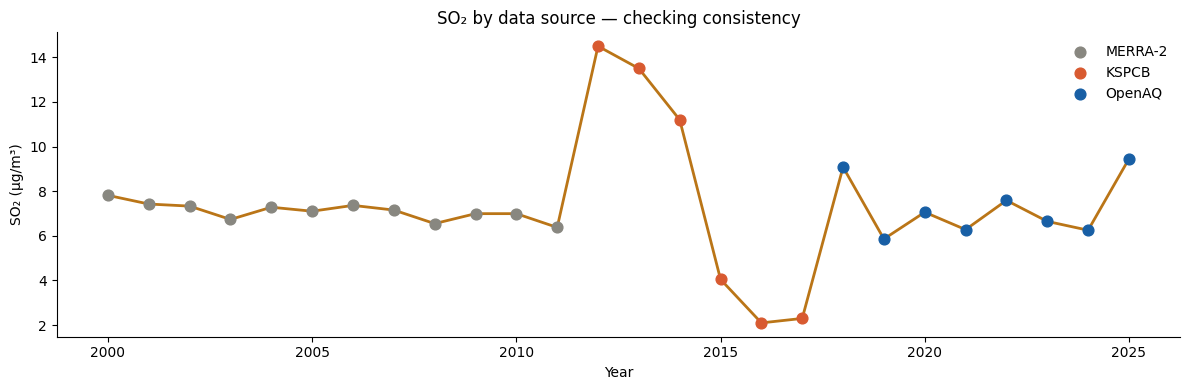

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_combined["year"], df_combined["so2"],
        color="#BA7517", linewidth=2, marker="o", markersize=5)

# Colour-code by source
sources = {
    "MERRA-2":  df_combined[df_combined["year"] <= 2011],
    "KSPCB":    df_combined[(df_combined["year"] >= 2012) &
                             (df_combined["year"] <= 2017)],
    "OpenAQ":   df_combined[df_combined["year"] >= 2018],
}
colors = {"MERRA-2": "#888780", "KSPCB": "#D85A30", "OpenAQ": "#185FA5"}

for source, data in sources.items():
    ax.scatter(data["year"], data["so2"],
               color=colors[source], s=60, zorder=4, label=source)

ax.set_title("SO₂ by data source — checking consistency")
ax.set_ylabel("SO₂ (µg/m³)")
ax.set_xlabel("Year")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Flag SO2 source for transparency
def so2_source(year):
    if year <= 2011:   return "MERRA-2"
    elif year <= 2017: return "KSPCB"
    else:              return "OpenAQ"

df_combined["so2_source"] = df_combined["year"].apply(so2_source)

# Mark SO2 as unreliable for cross-era comparison
df_combined["so2_reliable"] = df_combined["so2_source"] == "OpenAQ"

print("SO2 reliable years (OpenAQ only):")
print(df_combined[df_combined["so2_reliable"]][["year","so2"]].to_string(index=False))

SO2 reliable years (OpenAQ only):
 year   so2
 2018 9.080
 2019 5.860
 2020 7.060
 2021 6.280
 2022 7.590
 2023 6.648
 2024 6.253
 2025 9.450
